In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import glob
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# ============================================================
# CONFIGURACIÓN — cambia solo esta ruta
# ============================================================
CARPETA_DATOS = "."

# Bandas de interés 
BANDAS_ASIC     = ['Theta_ASIC', 'Alpha_ASIC', 'Beta_ASIC']
BANDAS_FFT_FILT = ['Theta_FFT_filt', 'Alpha_FFT_filt', 'Beta_FFT_filt']

# Colores para cada banda en gráficas
COLORES_BANDA = {
    'Theta': '#8338EC',
    'Alpha': '#06D6A0',
    'Beta' : '#FB5607',
}

# Colores para cada estímulo
COLORES_ESTIMULO = {
    'E1': '#3A86FF',
    'E2': '#FF006E',
    'E3': '#FFB703',
    'baseline': '#888888',
}

RANGOS = {
    'Theta': '4–8 Hz',
    'Alpha': '8–13 Hz',
    'Beta' : '13–30 Hz',
}

## Funciones de carga y limpieza

In [7]:
def cargar_csv(path):
    """
    Carga un CSV con las siguientes limpiezas:
    - NO descarta fila 0 porque grabadora ya descarta ventanas de calibración
    - Descarta filas con PoorSignal > 25
    - Crea columna 't' con tiempo relativo en segundos
    - Agrega columnas suavizadas con media móvil de 10 s
    - Agrega columna 'Estimulo' basada en la columna Marcador
    """
    df = pd.read_csv(path)
    df = df[df['PoorSignal'] <= 25].copy()
    df = df.reset_index(drop=True)

    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['t'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()

    # Media móvil de 10 s para suavizar picos de artefactos
    df['CLI_ASIC_suav']     = df['CLI_ASIC'].rolling(window=10, center=True, min_periods=1).mean()
    df['CLI_FFT_filt_suav'] = df['CLI_FFT_filt'].rolling(window=10, center=True, min_periods=1).mean()

    # ── Segmentación por estímulo ─────────────────────────────────────────
    # La columna Marcador tiene E1, E2, E3 en el segundo donde se presionó
    # la tecla. Rellenamos hacia adelante para saber a qué estímulo pertenece
    # cada segundo posterior al marcador.
    # Antes del primer marcador se etiqueta como 'baseline'.
    df['Estimulo'] = df['Marcador'].replace('', np.nan)
    df['Estimulo'] = df['Estimulo'].ffill()  # propagar hacia adelante
    df['Estimulo'] = df['Estimulo'].fillna('baseline')  # antes del E1 = baseline
    # ─────────────────────────────────────────────────────────────────────

    return df


def nombre_sesion(path):
    """Extrae un nombre legible del nombre de archivo."""
    base = os.path.basename(path).replace('.csv', '')
    partes = base.split('_')
    ignorar = {'sesion', 'sesion2', 'AC', 'sesion3', 'filtro', 'prueba'}
    nombre = ' '.join(p for p in partes if not p.startswith('202') and p not in ignorar)
    return nombre.strip().capitalize()


def imprimir_stats(df, nombre):
    """Imprime tabla de estadísticas básicas de la sesión."""
    dur = int(df['t'].max())
    print(f"  Duración válida   : {dur//60} min {dur%60} seg  ({len(df)} ventanas)")
    print(f"  Muestras/seg      : {df['MuestrasEnVentana'].mean():.0f}  (ideal: 512)")
    print(f"  Muestras ruidosas : {df['MuestrasRuidosas'].sum()}")
    print()

    # Estadísticas generales
    cols = ['CLI_ASIC', 'CLI_FFT_filt', 'Attention', 'Meditation']
    tabla = df[cols].describe().loc[['mean','std','min','max']].round(3)
    tabla.index = ['Media', 'Desv.Est.', 'Mínimo', 'Máximo']
    print("  === Estadísticas generales ===")
    print(tabla.to_string())
    print()

    # Estadísticas por estímulo si hay marcadores
    estimulos = df[df['Estimulo'] != 'baseline']['Estimulo'].unique()
    if len(estimulos) > 0:
        print("  === CLI_ASIC por estímulo ===")
        for est in sorted(estimulos):
            seg = df[df['Estimulo'] == est]
            print(f"  {est}: media={seg['CLI_ASIC'].mean():.3f}  "
                  f"stdev={seg['CLI_ASIC'].std():.3f}  "
                  f"dur={int(seg['t'].max()-seg['t'].min())}s  "
                  f"n={len(seg)} ventanas")
        print()

## Funciones de graficación

In [8]:
def graficar_bandas(df, nombre, metodo='ASIC'):
    """
    3 subplots apilados: Theta, Alpha, Beta.
    Muestra señal raw (tenue) + media móvil 10 s (gruesa).
    Si hay marcadores, agrega líneas verticales de colores.
    """
    if metodo == 'ASIC':
        cols = ['Theta_ASIC', 'Alpha_ASIC', 'Beta_ASIC']
        unidad = 'Potencia (u.a.)'
    else:
        cols = ['Theta_FFT_filt', 'Alpha_FFT_filt', 'Beta_FFT_filt']
        unidad = 'Potencia (µV² / Hz)'

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    fig.suptitle(f'Bandas {metodo} — {"P1"}', fontsize=14, fontweight='bold', y=1.01)

    bandas_nombres = ['Theta', 'Alpha', 'Beta']
    for ax, col, banda in zip(axes, cols, bandas_nombres):
        color = COLORES_BANDA[banda]
        rango = RANGOS[banda]
        suav  = df[col].rolling(window=10, center=True, min_periods=1).mean()

        ax.plot(df['t'], df[col], color=color, linewidth=0.8, alpha=0.3, label='Raw')
        ax.plot(df['t'], suav, color=color, linewidth=2.0, label='Media móvil 10 s')
        ax.set_ylabel(unidad, fontsize=9)
        ax.set_title(f'{banda} ({rango})', fontsize=10, loc='left')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)

        # Líneas verticales de marcadores
        _agregar_marcadores(ax, df)

    axes[-1].set_xlabel('Tiempo (s)')
    plt.tight_layout()
    plt.show()


def graficar_cli(df, nombre):
    """
    2 subplots: CLI_ASIC y CLI_FFT_filt suavizados.
    Con línea de media horizontal y marcadores de estímulo.
    """
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    fig.suptitle(f'Índice de Carga Cognitiva (CLI = Theta/Alpha) — {"P1"}',
                 fontsize=13, fontweight='bold')

    pares = [
        ('CLI_ASIC',     'CLI_ASIC_suav',     '#FB5607', 'CLI ASIC (Theta_ASIC / Alpha_ASIC)'),
        ('CLI_FFT_filt', 'CLI_FFT_filt_suav', '#3A86FF', 'CLI FFT filtrado (Theta_FFT_filt / Alpha_FFT_filt)'),
    ]

    for ax, (col_raw, col_suav, color, titulo) in zip(axes, pares):
        media = df[col_suav].mean()
        ax.plot(df['t'], df[col_raw], color=color, linewidth=0.7, alpha=0.25, label='Raw')
        ax.plot(df['t'], df[col_suav], color=color, linewidth=2.2, label='Media móvil 10 s')
        ax.axhline(media, color=color, linestyle='--', linewidth=1.3,
                   alpha=0.7, label=f'Media = {media:.2f}')
        ax.set_ylabel('Theta/Alpha\n(adimensional)')
        ax.set_title(titulo, fontsize=10, loc='left')
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(True, alpha=0.3)

        # Líneas verticales de marcadores
        _agregar_marcadores(ax, df)

    axes[-1].set_xlabel('Tiempo (s)')
    plt.tight_layout()
    plt.show()


def _agregar_marcadores(ax, df):
    """
    Agrega líneas verticales de colores donde hay marcadores E1, E2, E3.
    Se llama desde dentro de cada función de graficación.
    """
    marcadores = df[df['Marcador'].isin(['E1','E2','E3'])]
    for _, fila in marcadores.iterrows():
        color = COLORES_ESTIMULO.get(fila['Marcador'], 'white')
        ax.axvline(x=fila['t'], color=color, linewidth=1.5,
                   linestyle='--', alpha=0.8)
        ax.text(fila['t'] + 1, ax.get_ylim()[1] * 0.9,
                fila['Marcador'], color=color, fontsize=9, fontweight='bold')

## Análisis por estímulo
Compara CLI_ASIC entre estímulos dentro de la misma sesión.

In [9]:
def graficar_cli_por_estimulo(df, nombre):
    """
    Boxplot de CLI_ASIC por estímulo.
    Permite comparar visualmente si E1, E2 y E3 generan diferente carga.
    """
    estimulos = ['baseline', 'E1', 'E2', 'E3']
    datos = [df[df['Estimulo'] == e]['CLI_ASIC'].dropna() for e in estimulos]
    datos_validos = [(e, d) for e, d in zip(estimulos, datos) if len(d) > 0]

    if not datos_validos:
        print('No hay marcadores en esta sesión — no se puede comparar por estímulo')
        return

    etiquetas, valores = zip(*datos_validos)
    colores_box = [COLORES_ESTIMULO.get(e, '#888888') for e in etiquetas]

    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(valores, labels=etiquetas, patch_artist=True)

    for patch, color in zip(bp['boxes'], colores_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    # Agregar media como punto
    for i, (etiq, vals) in enumerate(zip(etiquetas, valores), 1):
        media = vals.mean()
        ax.plot(i, media, 'w*', markersize=12, label=f'{etiq} media={media:.2f}' if i == 1 else f'{etiq}={media:.2f}')

    ax.set_title(f'CLI_ASIC por estímulo — {"P1"}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Theta/Alpha (adimensional)')
    ax.set_xlabel('Segmento')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def graficar_cli_estimulos_linea(df, nombre):
    """
    CLI_ASIC suavizado en el tiempo con fondo de colores por estímulo.
    Más intuitivo para ver la evolución de la carga a lo largo de la sesión.
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    # Fondo de colores por segmento
    estimulos_orden = ['baseline', 'E1', 'E2', 'E3']
    for est in estimulos_orden:
        seg = df[df['Estimulo'] == est]
        if len(seg) == 0:
            continue
        color = COLORES_ESTIMULO.get(est, '#888888')
        ax.axvspan(seg['t'].min(), seg['t'].max(), alpha=0.1, color=color, label=est)

    # CLI suavizado
    ax.plot(df['t'], df['CLI_ASIC_suav'], color='white', linewidth=2.2, label='CLI_ASIC')
    ax.axhline(df['CLI_ASIC'].mean(), color='white', linestyle='--',
               linewidth=1.1, alpha=0.5, label=f'Media global={df["CLI_ASIC"].mean():.2f}')

    # Líneas de marcadores
    _agregar_marcadores(ax, df)

    ax.set_title(f'CLI_ASIC a lo largo de la sesión — {"P1"}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Theta/Alpha (adimensional)')
    ax.set_xlabel('Tiempo (s)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Ejecución — Análisis individual por sesión

Archivos encontrados: 1
 - CesarA.csv

  P1
  Duración válida   : 6 min 12 seg  (373 ventanas)
  Muestras/seg      : 513  (ideal: 512)
  Muestras ruidosas : 0

  === Estadísticas generales ===
           CLI_ASIC  CLI_FFT_filt  Attention  Meditation
Media         2.253         3.790     55.252      48.973
Desv.Est.     2.587         6.265     15.476      11.907
Mínimo        0.102         0.100     14.000      14.000
Máximo       32.518        72.813     97.000      83.000

  === CLI_ASIC por estímulo ===
  E1: media=1.756  stdev=1.655  dur=65s  n=66 ventanas
  E2: media=1.993  stdev=1.791  dur=132s  n=133 ventanas
  E3: media=2.101  stdev=2.043  dur=72s  n=73 ventanas



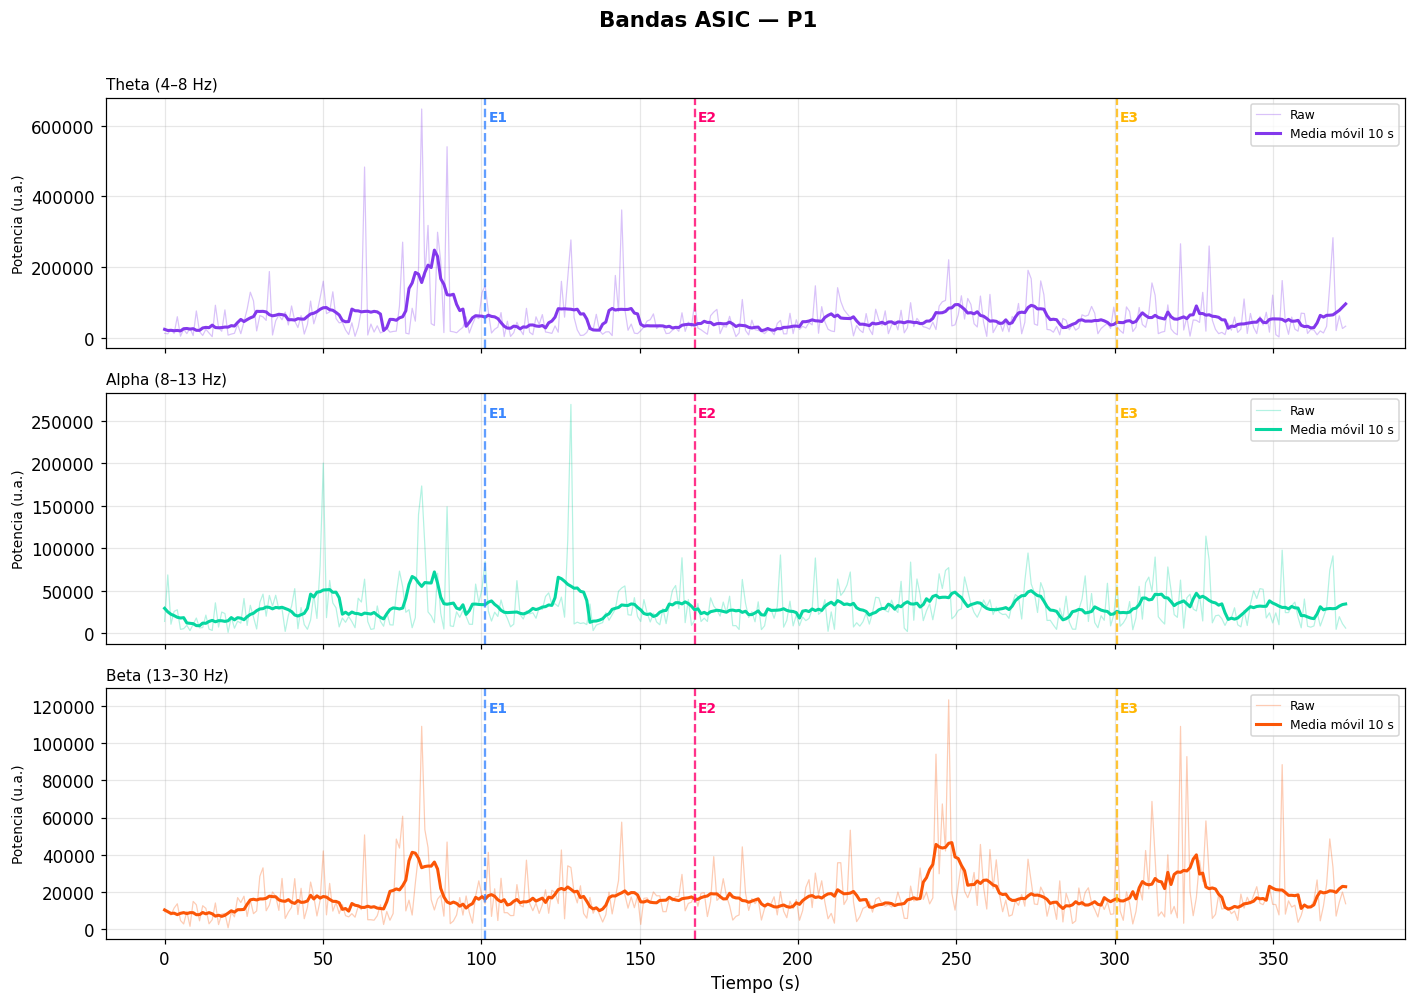

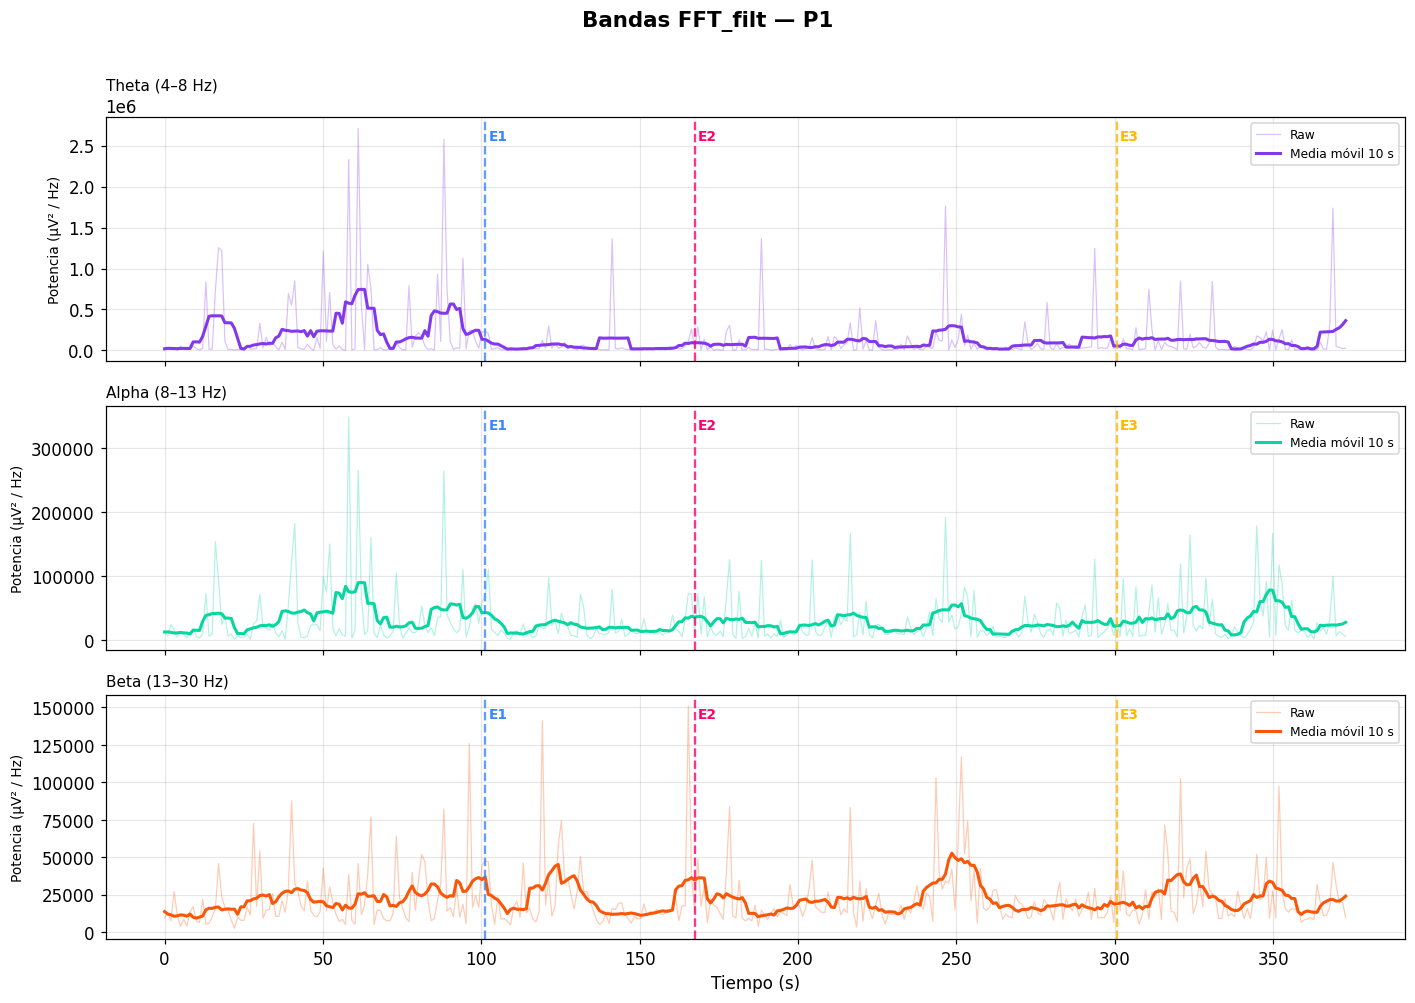

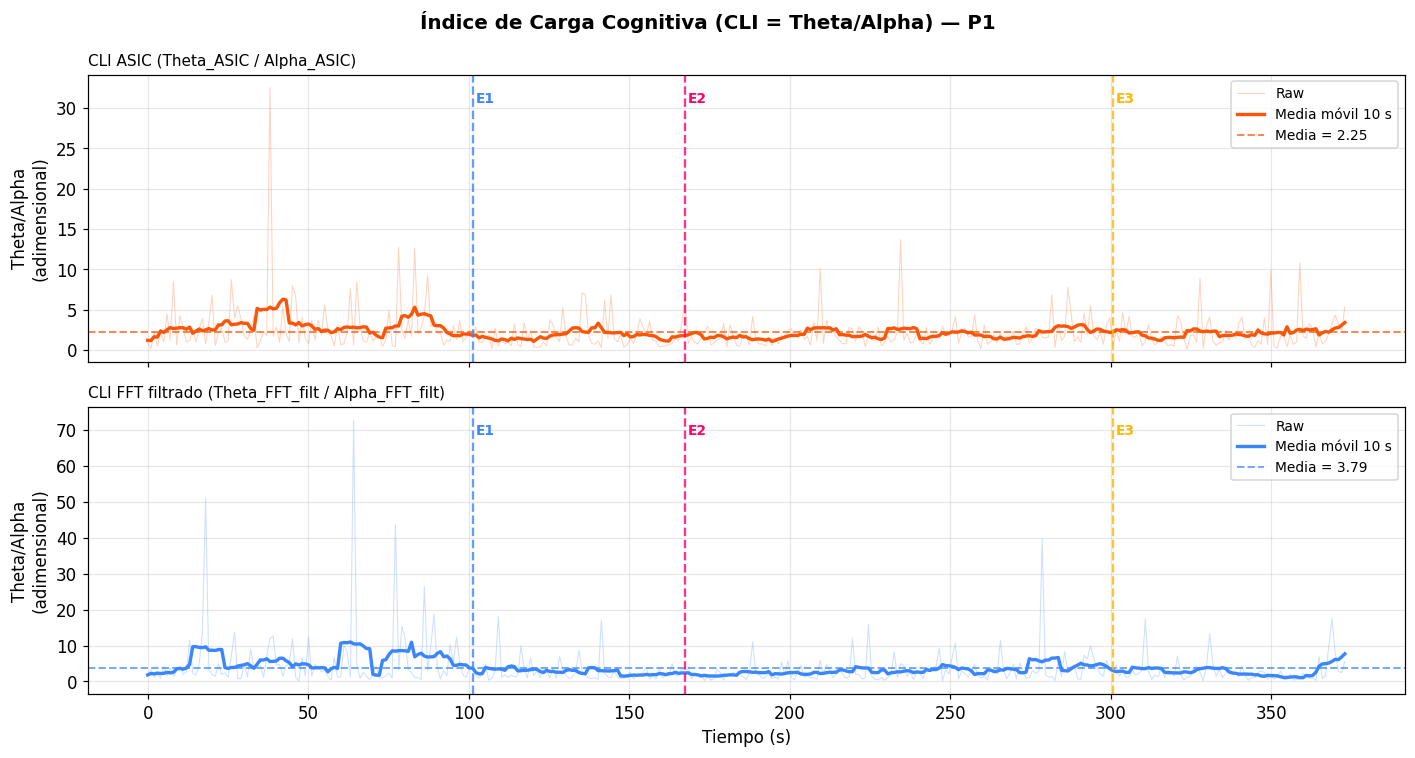

C:\Users\josee\AppData\Local\Temp\ipykernel_20460\1725490725.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(valores, labels=etiquetas, patch_artist=True)


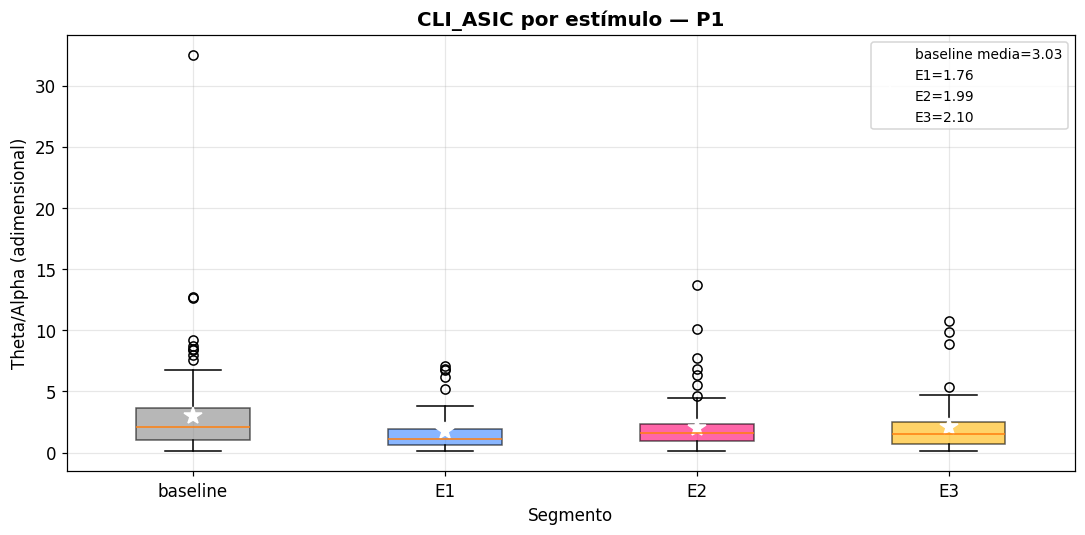

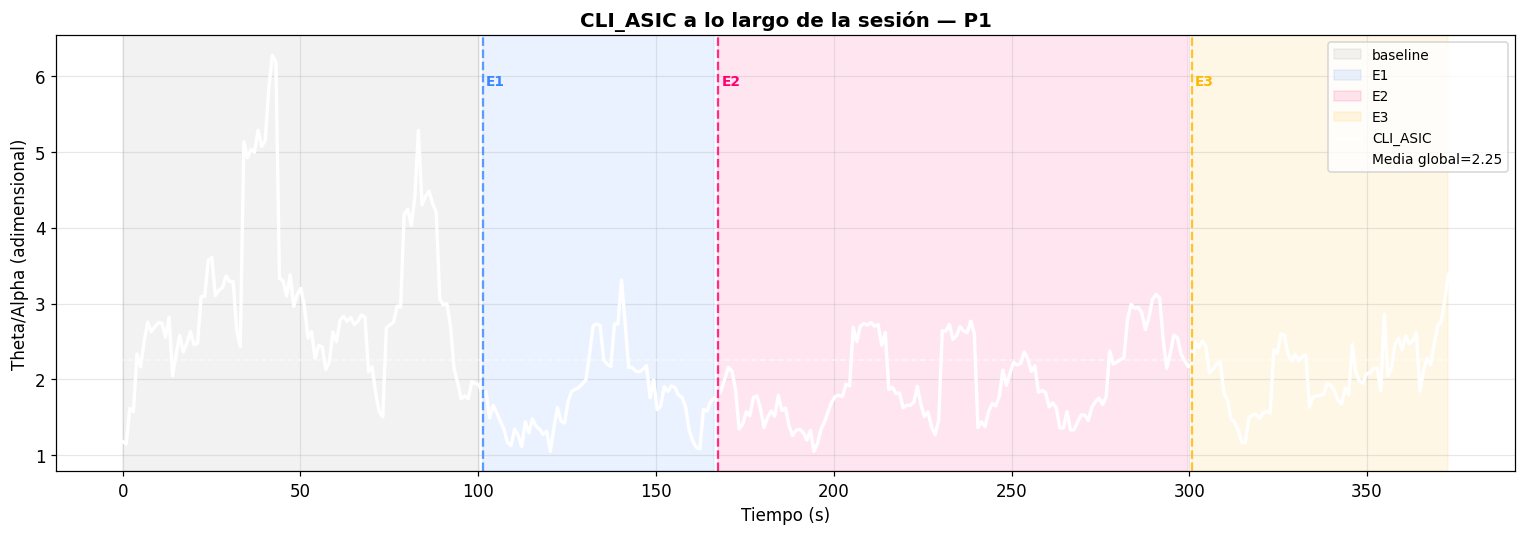

In [ ]:
archivos = ['P1-A.csv']
print(f'Archivos encontrados: {len(archivos)}')
for a in archivos:
    print(' -', os.path.basename(a))

datasets = {}

for path in archivos:
    nombre = nombre_sesion(path)
    print(f'\n{"="*52}')
    print(f'  {"P1"}')
    print(f'{"="*52}')

    df = cargar_csv(path)
    imprimir_stats(df, nombre)

    # Gráficas de bandas
    graficar_bandas(df, nombre, metodo='ASIC')
    graficar_bandas(df, nombre, metodo='FFT_filt')

    # CLI en el tiempo con marcadores
    graficar_cli(df, nombre)

    # Análisis por estímulo (solo si hay marcadores)
    if df['Marcador'].isin(['E1','E2','E3']).any():
        graficar_cli_por_estimulo(df, nombre)
        graficar_cli_estimulos_linea(df, nombre)

    datasets[nombre] = df

## Comparativa entre sesiones

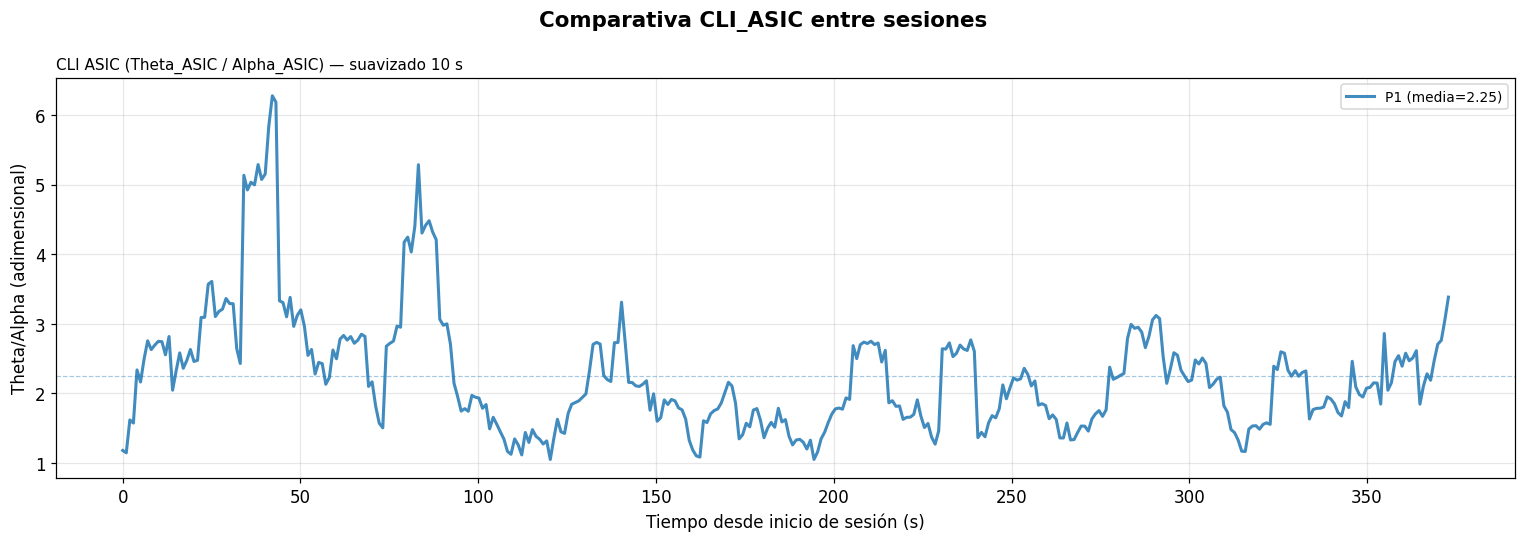

In [11]:
def comparar_cli_sesiones(datasets):
    """
    CLI_ASIC suavizado de todas las sesiones en una sola figura.
    Solo muestra CLI_ASIC — es la métrica principal.
    """
    colores = cm.tab10(np.linspace(0, 1, len(datasets)))

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle('Comparativa CLI_ASIC entre sesiones', fontsize=14, fontweight='bold')

    for (nombre, df), color in zip(datasets.items(), colores):
        media = df['CLI_ASIC_suav'].mean()
        ax.plot(df['t'], df['CLI_ASIC_suav'],
                linewidth=2, label=f'{"P1"} (media={media:.2f})',
                color=color, alpha=0.85)
        ax.axhline(media, color=color, linewidth=0.8, linestyle='--', alpha=0.4)

    ax.set_title('CLI ASIC (Theta_ASIC / Alpha_ASIC) — suavizado 10 s', fontsize=10, loc='left')
    ax.set_xlabel('Tiempo desde inicio de sesión (s)')
    ax.set_ylabel('Theta/Alpha (adimensional)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


comparar_cli_sesiones(datasets)

## Tabla resumen comparativa
Media del CLI por sesión y por estímulo, ordenada de mayor a menor carga cognitiva.

In [12]:
resumen = []
for nombre, df in datasets.items():
    dur = int(df['t'].max())
    fila = {
        'Sesión'              : "P1",
        'Duración (s)'        : dur,
        'CLI_ASIC media'      : round(df['CLI_ASIC'].mean(), 3),
        'CLI_FFT_filt media'  : round(df['CLI_FFT_filt'].mean(), 3),
        'Attention media'     : round(df['Attention'].mean(), 1),
        'Meditation media'    : round(df['Meditation'].mean(), 1),
    }

    # Agregar el CLI calculado con tu algoritmo FFT por estímulo
    for est in ['E1', 'E2', 'E3']:
        seg = df[df['Estimulo'] == est]
        fila[f'CLI_FFT_filt_{est}'] = round(seg['CLI_FFT_filt'].mean(), 3) if len(seg) > 0 else '-'

    resumen.append(fila)

# Ordenar la tabla utilizando tu métrica filtrada
tabla = pd.DataFrame(resumen).sort_values('CLI_FFT_filt media', ascending=False)
tabla = tabla.reset_index(drop=True)
tabla.index = tabla.index + 1
print(tabla.to_string())

  Sesión  Duración (s)  CLI_ASIC media  CLI_FFT_filt media  Attention media  Meditation media  CLI_FFT_filt_E1  CLI_FFT_filt_E2  CLI_FFT_filt_E3
1     P1           372           2.253                3.79             55.3              49.0            2.745            3.129            2.928
